# GRPO-PBE — Analysis & Results

Loads the JSON eval outputs from `data/eval_results_{base,sft,grpo}.json`
(produced by `python -m grpo_pbe.evaluate <ckpt> <label>`) and renders the
headline comparison table plus cherry-picked qualitative examples.

Run cells top-to-bottom after both training runs and all three evals complete.

In [1]:
import json
from pathlib import Path

results = {}
for label in ["base", "sft", "grpo"]:
    path = Path(f"../data/eval_results_{label}.json")
    if path.exists():
        with open(path) as f:
            results[label] = json.load(f)
        print(f"Loaded {label}: {len(results[label]['results'])} examples")
    else:
        print(f"MISSING: {path} — run `python -m grpo_pbe.evaluate ... {label}` first")

Loaded base: 200 examples
Loaded sft: 200 examples
Loaded grpo: 200 examples


## Headline results

Overall + per-difficulty accuracy. Mean think-length is the
GRPO-only “aha moment” signal.

In [2]:
import pandas as pd

rows = []
for label in ["base", "sft", "grpo"]:
    if label not in results:
        continue
    m = results[label]["metrics"]
    rows.append({
        "Model":  label,
        "Easy":   f"{m.get('easy_accuracy', 0):.1%}",
        "Medium": f"{m.get('medium_accuracy', 0):.1%}",
        "Hard":   f"{m.get('hard_accuracy', 0):.1%}",
        "Overall": f"{m.get('overall_accuracy', 0):.1%}",
        "Mean think length": (f"{m['mean_think_length']:.0f}"
                              if "mean_think_length" in m else "—"),
    })

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))
df

| Model   | Easy   | Medium   | Hard   | Overall   | Mean think length   |
|:--------|:-------|:---------|:-------|:----------|:--------------------|
| base    | 0.0%   | 0.0%     | 0.0%   | 0.0%      | 110                 |
| sft     | 97.8%  | 95.0%    | 100.0% | 97.0%     | —                   |
| grpo    | 1.1%   | 0.0%     | 0.0%   | 0.5%      | 119                 |


,Model,Easy,Medium,Hard,Overall,Mean think length
0,base,0.0%,0.0%,0.0%,0.0%,110
1,sft,97.8%,95.0%,100.0%,97.0%,—
2,grpo,1.1%,0.0%,0.0%,0.5%,119


## Training curves

GRPO run is logged to W&B (project: `grpo-pbe`, run: `grpo-run`).
Four tracked curves: mean reward, mean think-length, KL, format compliance.

Either export charts manually from the W&B UI and embed them under
`reports/`, or use the wandb API below.

In [3]:
# Uncomment after the run is logged. Replace USERNAME/run-id.
# import wandb
# api = wandb.Api()
# run = api.run("USERNAME/grpo-pbe/grpo-run")
# history = run.history(keys=["train/reward", "train/kl", "train/completion_length"])
# history.plot(x="_step", subplots=True, figsize=(10, 8))
pass

## Qualitative examples

Top hard-tier wins for GRPO (when present) plus a couple of failures.
Useful for the blog post.

In [4]:
grpo_results = results.get("grpo", {}).get("results", [])

hard_correct = [r for r in grpo_results if r["difficulty"] == "hard" and r["correct"]]
hard_wrong   = [r for r in grpo_results if r["difficulty"] == "hard" and not r["correct"]]

print("=== HARD examples GRPO got right ===")
for r in hard_correct[:3]:
    print(f"\nTemplate: {r['template_name']}")
    print(f"Response: {r['response'][:300]}{'...' if len(r['response']) > 300 else ''}")
    print(f"Code: {r['code']}")
    print(f"Gold: {r['gold_code']}")

print("\n=== HARD examples GRPO got wrong ===")
for r in hard_wrong[:2]:
    print(f"\nTemplate: {r['template_name']}")
    print(f"Response: {r['response'][:300]}{'...' if len(r['response']) > 300 else ''}")
    print(f"Code: {r['code']}")
    print(f"Gold: {r['gold_code']}")

=== HARD examples GRPO got right ===

=== HARD examples GRPO got wrong ===

Template: extract_sort_dedup_join
Response: <think>The pattern seems to be rearranging words while keeping certain characters fixed.</think>
<code>x.split(' ').reverse().join('')</code>
Code: x.split(' ').reverse().join('')
Gold: ' '.join(sorted(set(w.lower() for w in x.split())))

Template: split_filter_join
Response: <think>The task involves replacing spaces and commas with vertical bars (`|`). We need to iterate through each character of the string and replace spaces and commas with a vertical bar.</think>

<code>
def transform_string(x):
    result = ""
    for char in x:
        if char == " " or char == ",":...
Code: def transform_string(x):
    result = ""
    for char in x:
        if char == " " or char == ",":
            result += "|"
        else:
            result += char
    return result
Gold: ' | '.join(s.strip() for s in x.split(',') if s.strip())


## Reasoning length distribution

How long does GRPO’s reasoning trace get for each difficulty tier?
If the hard tier shows visibly longer traces, that's the “aha moment”
the blog post leans on.

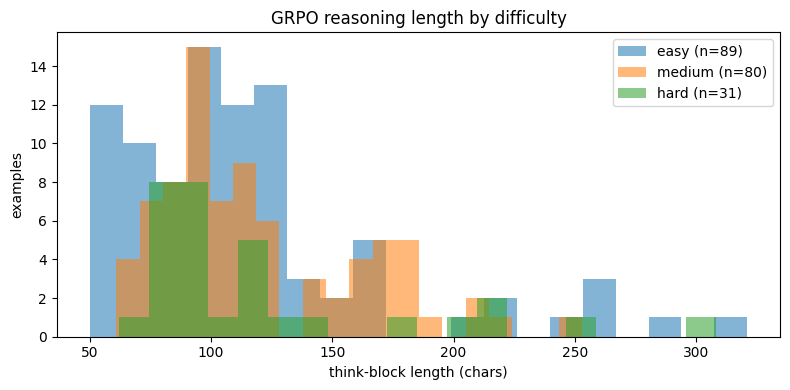

In [5]:
import matplotlib.pyplot as plt

grpo_results = results.get("grpo", {}).get("results", [])
if grpo_results:
    by_diff = {}
    for r in grpo_results:
        by_diff.setdefault(r["difficulty"], []).append(r["think_length"])

    fig, ax = plt.subplots(figsize=(8, 4))
    for diff in ["easy", "medium", "hard"]:
        if diff in by_diff:
            ax.hist(by_diff[diff], bins=20, alpha=0.55, label=f"{diff} (n={len(by_diff[diff])})")
    ax.set_xlabel("think-block length (chars)")
    ax.set_ylabel("examples")
    ax.set_title("GRPO reasoning length by difficulty")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No GRPO results loaded yet.")